# C07 · Stochastic volatility: a Value-at-Risk number you can defend

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | S&P 500 daily closes and log-returns, May 2008 - December 2013 |
| **Skills** | Designing posterior predictive checks with your own test statistics · heavy-tailed likelihoods · a latent state **per observation** (random-walk log-volatility) · centred vs non-centred time series · reading low ESS and divergences instead of ignoring them · one-step-ahead forecasts from a state-space model · sequential updating without refitting · back-testing a risk number |

## The brief

You have joined the market-risk desk of a small asset manager. Every evening the desk
publishes a **one-day 99% Value-at-Risk** (VaR) for its S&P 500 book: the loss that
tomorrow's return should exceed on only 1 day in 100. Capital is held against that number,
and the regulator back-tests it the simple way - by counting the days on which the loss
was worse than the VaR.

The desk's current model is one line: daily returns are Normal with a constant mean and a
constant volatility, estimated from history. The head of risk suspects it is wrong in two
ways at once - *"too relaxed the week everything falls apart, and far too scared for years
afterwards"* - and asks you for a replacement, plus the evidence that it is better.

You will build the model on data up to **30 June 2011** and be judged on the 2.5 years
that follow, which the model never sees during fitting.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task3")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task3", vol_of_vol=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy import stats

from pymc_challenges import Hints, data

# PyTensor 3.3 logs a long but harmless "Rewrite failure" traceback when it compiles
# pm.GaussianRandomWalk with more than 127 steps. The model is unaffected; keep the log quiet.
logging.getLogger("pytensor.graph.rewriting.basic").setLevel(logging.CRITICAL)

RANDOM_SEED = 2008
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

h = Hints("C07")
h.tasks()

**C07 - Stochastic volatility: a Value-at-Risk number you can defend**

- `task0` - What do returns look like? (3 hints, 2 check(s))
- `task1` - The desk's model and checks that expose it (3 hints, 2 check(s))
- `task2` - Fat tails (3 hints, 1 check(s))
- `task3` - Latent log-volatility and a sampler in trouble (3 hints, 2 check(s))
- `task4` - Does the volatility path make sense? (3 hints, 2 check(s))
- `task5` - Tomorrow's VaR (3 hints, 2 check(s))
- `task6` - Back-test and recommend (3 hints, 2 check(s))

## The data

`change` is the daily log-return of the index. Returns are easier to read (and to put
priors on) in **percent**, so that is the unit used everywhere below, including in the
checks: `ret = 100 * change`.

The file runs to 2019. We use only the first 5.5 years: a latent volatility *per trading
day* makes the model grow with the data, and 800 training days keep each fit to about a
minute. `train` is all you may fit on; `test` is for Tasks 5-6 only.

In [2]:
data.describe("sp500")
sp500 = data.load("sp500")
sp500["ret"] = 100 * sp500["change"]

train = sp500.loc[:"2011-06-30"]
test = sp500.loc["2011-07-01":"2013-12-31"]
print(f"train: {train.index[0].date()} to {train.index[-1].date()}, {len(train)} days")
print(f"test:  {test.index[0].date()} to {test.index[-1].date()}, {len(test)} days")
train.head()

sp500: Daily close and log-return ('change').
  source: S&P 500 index daily closes (2008-2019), via pymc-examples.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/SP500.csv
train: 2008-05-02 to 2011-06-30, 798 days
test:  2011-07-01 to 2013-12-31, 629 days


,Close,change,ret
Date,,,
2008-05-02,1413.900024,0.003230,0.323038
2008-05-05,1407.489990,-0.004544,-0.454389
2008-05-06,1418.260010,0.007623,0.762281
2008-05-07,1392.569946,-0.018280,-1.827985
2008-05-08,1397.680054,0.003663,0.366284


## Task 0 · What do returns look like?

**Deliver** (on `train`) the evidence for or against each half of the desk's assumption:

1. *Normal:* compare the distribution of returns with a Normal of the same mean and standard
   deviation, in a way that shows the **tails**. Report the excess kurtosis.
2. *Constant volatility:* plot the autocorrelation function of the returns and of their
   absolute values, side by side. What does each say?

sd 1.83%, excess kurtosis 6.7, skewness -0.22
largest |return| 11.0% = 6.0 sd
ACF of |returns|: lag 1 0.25, mean of lags 1-10 0.35


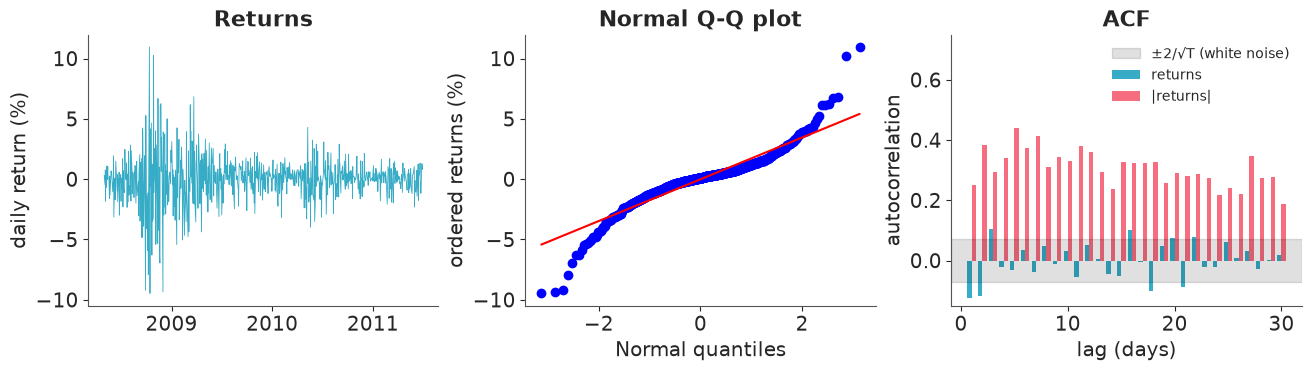

In [3]:
r_train = train["ret"].values
T = len(r_train)


def acf(x, max_lag):
    """Sample autocorrelation at lags 1..max_lag."""
    x = x - x.mean()
    return np.array([np.dot(x[:-k], x[k:]) for k in range(1, max_lag + 1)]) / np.dot(x, x)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(train.index, r_train, lw=0.6)
axes[0].set(ylabel="daily return (%)", title="Returns", xticks=pd.to_datetime(["2009", "2010", "2011"]))
axes[0].set_xticklabels(["2009", "2010", "2011"])

stats.probplot(r_train, dist="norm", plot=axes[1])
axes[1].set(title="Normal Q-Q plot", xlabel="Normal quantiles", ylabel="ordered returns (%)")

lags = np.arange(1, 31)
axes[2].bar(lags - 0.2, acf(r_train, 30), width=0.4, label="returns")
axes[2].bar(lags + 0.2, acf(np.abs(r_train), 30), width=0.4, label="|returns|")
axes[2].axhspan(-2 / np.sqrt(T), 2 / np.sqrt(T), color="k", alpha=0.12, label="±2/√T (white noise)")
axes[2].set(xlabel="lag (days)", ylabel="autocorrelation", title="ACF", ylim=(-0.15, 0.75))
axes[2].legend(loc="upper right", fontsize=10)

excess_kurtosis = stats.kurtosis(r_train)
acf_abs_lag1 = acf(np.abs(r_train), 1)[0]
print(f"sd {r_train.std():.2f}%, excess kurtosis {excess_kurtosis:.1f}, skewness {stats.skew(r_train):.2f}")
print(f"largest |return| {np.abs(r_train).max():.1f}% = {np.abs(r_train).max() / r_train.std():.1f} sd")
print(f"ACF of |returns|: lag 1 {acf_abs_lag1:.2f}, mean of lags 1-10 {acf(np.abs(r_train), 10).mean():.2f}")

In [4]:
assert h.check("task0", excess_kurtosis=excess_kurtosis, acf_abs_lag1=acf_abs_lag1)

- PASS `excess_kurtosis` = 6.736 is consistent with the reference solution.
- PASS `acf_abs_lag1` = 0.2521 is consistent with the reference solution.

Both halves fail, and the two failures are the same phenomenon seen from two sides.

- **Tails.** The Q-Q plot bends away from the line at both ends, and the excess kurtosis is
  far from the Normal's zero. The largest move is six standard deviations, which a Normal
  would produce about once in two million years of trading.
- **Clustering.** The direction of tomorrow's return is close to unpredictable - the ACF of
  the returns is small (a few lags poke outside the white-noise band, with no consistent
  sign). The *size* of tomorrow's return is very predictable: the ACF of $|r_t|$ stays
  between about 0.2 and 0.45 for all 30 lags. Large moves follow large moves.

A mixture of calm days with small variance and crisis days with large variance *is* a
fat-tailed distribution, so clustering alone can generate the kurtosis. Keep that in mind
for Task 2.

## Task 1 · The desk's model, and checks that expose it

Fit the desk's model: $r_t \sim \text{Normal}(\mu, \sigma)$, both constant.

**Deliver**
1. The fit, with priors that make sense for daily returns in percent.
2. A posterior predictive check built on **test statistics you choose yourself** - at
   least three, each aimed at something a VaR number depends on. For each one: the
   distribution of the statistic over replicated datasets, the observed value, and the
   posterior predictive p-value $P(T(y^\text{rep}) \ge T(y))$.
3. One sentence per statistic: what does the model get wrong, and would a density overlay
   (`az.plot_ppc_dist`) have shown it?

### Solution

Daily index returns are a fraction of a percent on average and a percent or two in size:
`Normal(0, 0.5)` for $\mu$ and `HalfNormal(3)` for $\sigma$ are weak on that scale.

In [5]:
with pm.Model(coords={"date": train.index}) as normal_model:
    mu = pm.Normal("mu", 0, 0.5)
    sigma = pm.HalfNormal("sigma", 3)
    pm.Normal("ret", mu, sigma, observed=r_train, dims="date")
    normal_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.sample_posterior_predictive(normal_idata, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)

az.summary(normal_idata, round_to=3)

NUTS[nutpie]: [mu, sigma]


Sampling: [ret]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-0.008,0.065,-0.110,0.097,4225.169,2797.66,1.0,0.001,0.001
sigma,1.832,0.045,1.761,1.907,4352.660,3094.89,1.0,0.001,0.001


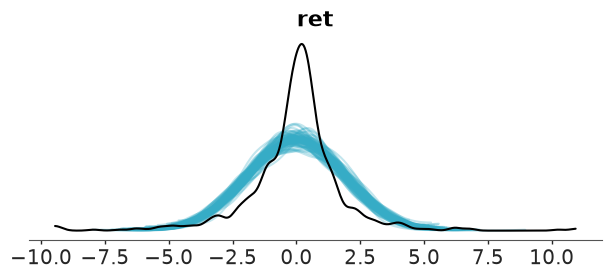

In [6]:
az.plot_ppc_dist(normal_idata, num_samples=100);

The overlay hints at a problem - the data are more peaked than the replications - but the
tails, where VaR lives, are invisible at this scale, and a density cannot show time
dependence at all. So we ask pointed questions instead. Three statistics, each tied to the
job:

- **excess kurtosis** - how heavy are the tails overall?
- **largest absolute return** - the single worst day is what a risk model exists for;
- **mean ACF of $|r|$ over lags 1-10** - does risk persist from day to day?

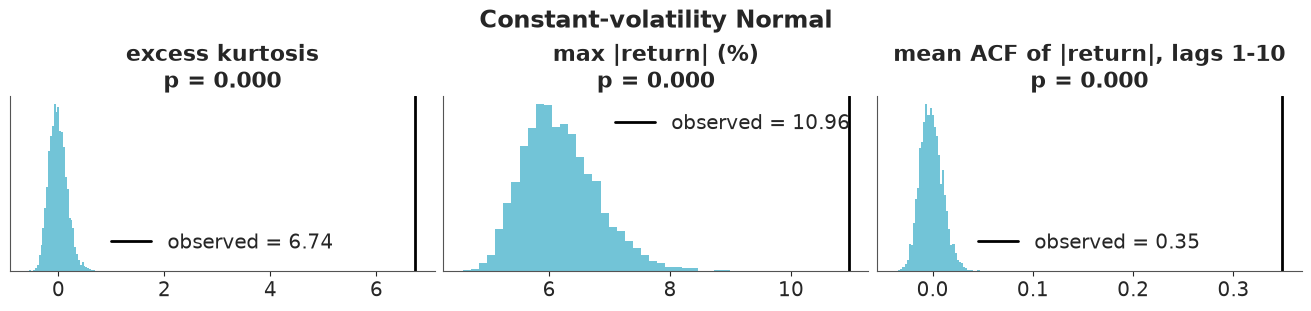

In [7]:
def mean_acf_abs(x, max_lag=10):
    """Mean autocorrelation of |x| over lags 1..max_lag, along the last axis."""
    a = np.abs(x) - np.abs(x).mean(axis=-1, keepdims=True)
    denom = (a * a).sum(axis=-1)
    return np.mean([(a[..., :-k] * a[..., k:]).sum(axis=-1) / denom for k in range(1, max_lag + 1)], axis=0)


T_STATS = {
    "excess kurtosis": lambda x: stats.kurtosis(x, axis=-1),
    "max |return| (%)": lambda x: np.abs(x).max(axis=-1),
    "mean ACF of |return|, lags 1-10": mean_acf_abs,
}


def ppc_stats(idata, title, log_x=()):
    """Histogram of each test statistic over replicated datasets, with the observed value and p-value."""
    rep = az.extract(idata, group="posterior_predictive", var_names="ret").transpose("sample", "date").values
    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    ppp = {}
    for ax, (name, fn) in zip(axes, T_STATS.items()):
        t_rep, t_obs = fn(rep), fn(r_train)
        ppp[name] = float((t_rep >= t_obs).mean())
        bins = np.geomspace(t_rep.min(), t_rep.max(), 40) if name in log_x else 40
        ax.hist(t_rep, bins=bins, color="C0", alpha=0.7)
        ax.axvline(t_obs, color="k", lw=2, label=f"observed = {t_obs:.2f}")
        ax.set(title=f"{name}\np = {ppp[name]:.3f}", yticks=[], xscale="log" if name in log_x else "linear")
        ax.legend()
    fig.suptitle(title)
    return ppp


normal_ppp = ppc_stats(normal_idata, "Constant-volatility Normal")

In [8]:
assert h.check("task1", sigma=normal_idata.posterior["sigma"].mean(), ppp_kurtosis=normal_ppp["excess kurtosis"])

- PASS `sigma` = 1.832 is consistent with the reference solution.
- PASS `ppp_kurtosis` = 0 is consistent with the reference solution.

Three p-values of zero: in 4000 replicated histories the model never once produces tails,
a worst day, or persistence anything like the real ones.

- *Kurtosis:* replications sit around 0, the data near 7.
- *Worst day:* the model's worst day in 800 is about 6%; the market delivered 11%.
- *Clustering:* replications have no memory (ACF around 0 ± 0.02); the data have 0.35.

`az.plot_ppc_tstat(idata, t_stat=...)` draws the same kind of plot and accepts `"max"`, a
quantile, or your own function. The point is not the plotting function but choosing $T$:
a PPC is only as sharp as the question it asks.

## Task 2 · Fat tails

The textbook fix for fat tails is a Student-t likelihood. Keep $\mu$ and the scale constant.

**Deliver** the fit, the **same** predictive checks as in Task 1, and a verdict: which
failures are fixed, which are not, and is any statistic now wrong *in the other direction*?
Explain what the posterior of the degrees of freedom $\nu$ is telling you.

In [9]:
with pm.Model(coords={"date": train.index}) as student_model:
    mu = pm.Normal("mu", 0, 0.5)
    sigma = pm.HalfNormal("sigma", 3)
    nu = pm.Gamma("nu", 2, 0.1)
    pm.StudentT("ret", nu=nu, mu=mu, sigma=sigma, observed=r_train, dims="date")
    student_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.sample_posterior_predictive(student_idata, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)

az.summary(student_idata, round_to=3)

NUTS[nutpie]: [mu, sigma, nu]


Sampling: [ret]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.095,0.041,0.029,0.160,3800.498,3025.103,1.000,0.001,0.001
sigma,0.908,0.050,0.826,0.988,1840.706,2270.260,1.001,0.001,0.001
nu,2.083,0.212,1.761,2.436,1839.767,2203.360,1.000,0.005,0.003


{'excess kurtosis': 0.988, 'max |return| (%)': 0.984, 'mean ACF of |return|, lags 1-10': 0.0}


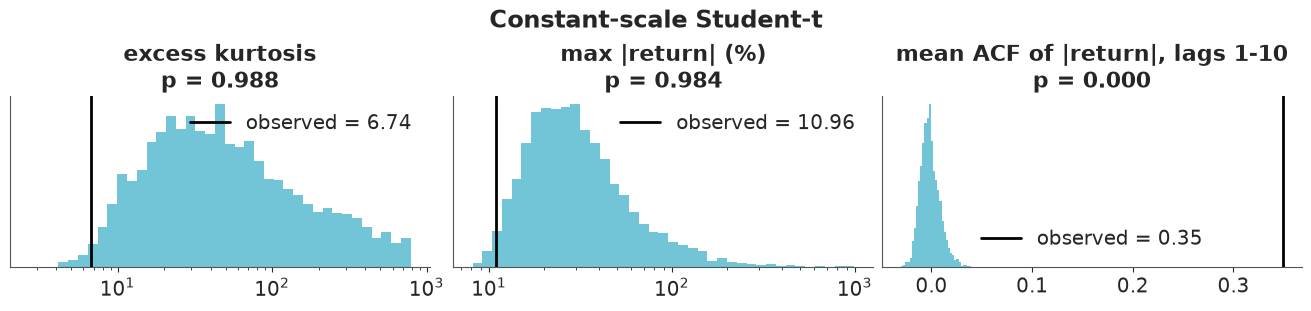

In [10]:
student_ppp = ppc_stats(student_idata, "Constant-scale Student-t", log_x=("excess kurtosis", "max |return| (%)"))
print({k: round(v, 3) for k, v in student_ppp.items()})

In [11]:
assert h.check("task2", nu=student_idata.posterior["nu"].mean())

- PASS `nu` = 2.083 is consistent with the reference solution.

`Gamma(2, 0.1)` is the usual weak prior for $\nu$ (mean 20, so "nearly Normal" unless the
data object). The data object violently: $\nu \approx 2$, the edge of infinite variance.

- *Clustering* is untouched: p = 0. A t distribution with independent draws has fat tails
  but no memory.
- *Tails* are now wrong **in the other direction** (note the log axes). With $\nu \approx 2$
  a typical replicated history contains a one-day move of more than 25%, and the observed
  kurtosis and worst day sit in the far *left* tail of the replications (p close to 1).

Why so extreme? One constant scale has to serve both the calm of 2010 and the panic of
October 2008. The only way a single t distribution can do that is a small scale for the
calm days and absurdly heavy tails to reach the crisis days. It is describing a *mixture
of volatility regimes* as if it were one distribution. The fat tails were mostly a symptom;
the disease is that volatility changes over time.

## Task 3 · Let volatility move

Model the **log-volatility as a latent random walk**: each day has its own volatility,
tomorrow's is today's plus a small shock, and returns are Student-t around $\mu$ with that
day's scale. That is one latent variable per trading day - about 800 parameters.

**Deliver**
1. The model, with a prior on the random walk's innovation scale (the "vol of vol") that
   you can defend: how much can volatility plausibly change in one day?
2. Your **first** fit and an honest reading of its diagnostics. Do not stop at "no
   divergences": check `r_hat` and ESS of *every* parameter, and find which one is in
   trouble.
3. A diagnosis (why is this posterior hard to sample?), a fix, and a final fit with clean
   diagnostics. If a fix trades one problem for another, show that too, and show that your
   final answer did not change with the sampler settings.

Budget: a fit takes about a minute. If you need more than three or four, think rather
than wait.

### Solution

$$
\begin{aligned}
r_t &\sim \text{StudentT}(\nu,\ \mu,\ e^{v_t}) \\
v_t &= v_{t-1} + \sigma_v\,\epsilon_t, \qquad \epsilon_t \sim \text{Normal}(0, 1)
\end{aligned}
$$

**Prior on $\sigma_v$.** It lives on the log scale, so it is a *relative* change per day:
$\sigma_v = 0.1$ means volatility typically moves by 10% a day and can double within a
couple of weeks. `HalfNormal(0.2)` covers everything from "almost constant" to "doubles in
a few days". Much wider priors (say `HalfNormal(5)`) put mass on volatility paths that are
pure noise, able to explain every return as its own volatility spike.

**First attempt**: the way the model is written in the maths - `pm.GaussianRandomWalk`.

In [12]:
def sv_model(centred):
    with pm.Model(coords={"date": train.index}) as model:
        vol_of_vol = pm.HalfNormal("vol_of_vol", 0.2)
        nu = pm.Gamma("nu", 2, 0.1)
        mu = pm.Normal("mu", 0, 0.5)
        if centred:
            log_vol = pm.GaussianRandomWalk(
                "log_vol", sigma=vol_of_vol, init_dist=pm.Normal.dist(0, 1), dims="date"
            )
        else:
            log_vol_0 = pm.Normal("log_vol_0", 0, 1)
            z = pm.Normal("z", 0, 1, dims="date")
            log_vol = pm.Deterministic("log_vol", log_vol_0 + pt.cumsum(vol_of_vol * z), dims="date")
        pm.StudentT("ret", nu=nu, mu=mu, sigma=pm.math.exp(log_vol), observed=r_train, dims="date")
    return model


def report(idata, label):
    """Divergences plus r_hat / ESS for the scalar parameters and the worst of the 800 log-vols."""
    summary = az.summary(idata, var_names=["vol_of_vol", "nu", "mu"], round_to=3)
    path = az.summary(idata, var_names=["log_vol"])
    print(f"{label}: {int(idata.sample_stats['diverging'].sum())} divergences; "
          f"log_vol worst r_hat {path.r_hat.max():.3f}, lowest ess_bulk {path.ess_bulk.min():.0f}")
    return summary[["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]]


centred_model = sv_model(centred=True)
with centred_model:
    centred_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

report(centred_idata, "centred")

NUTS[nutpie]: [vol_of_vol, nu, mu, log_vol]


centred: 0 divergences; log_vol worst r_hat 1.006, lowest ess_bulk 693


,mean,sd,ess_bulk,ess_tail,r_hat
vol_of_vol,0.087,0.014,67.955,59.097,1.081
nu,16.369,9.510,1062.261,1498.307,1.000
mu,0.110,0.035,3541.449,2559.998,1.002


Zero divergences, and the volatility path itself mixes acceptably - a reader in a hurry
would ship this. But look at the `vol_of_vol` row: an `r_hat` well above 1.01 and an
effective sample size in the tens from 4000 draws. That parameter decides how fast the
VaR reacts to news, so it is exactly the one we cannot afford to get wrong.

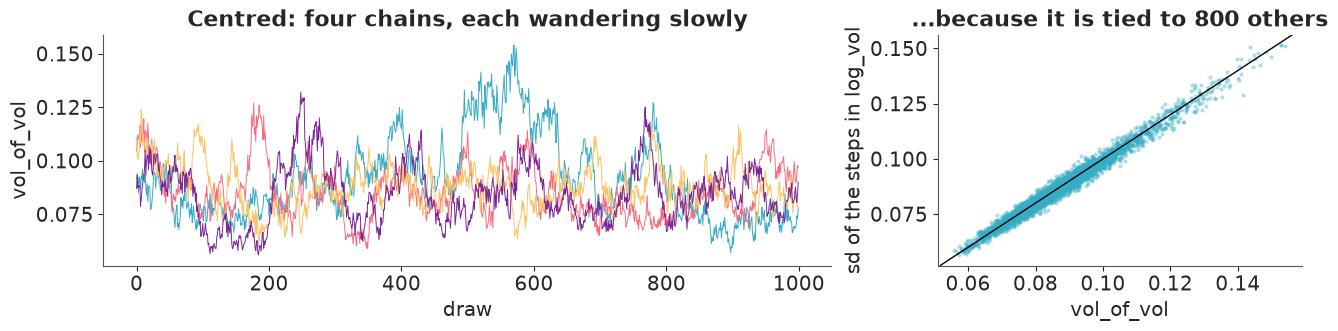

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), width_ratios=[2, 1])
for c in centred_idata.posterior.chain.values:
    axes[0].plot(centred_idata.posterior["vol_of_vol"].sel(chain=c), lw=0.7)
axes[0].set(xlabel="draw", ylabel="vol_of_vol", title="Centred: four chains, each wandering slowly")

cp = centred_idata.posterior
roughness = np.sqrt((cp["log_vol"].diff("date") ** 2).mean("date"))  # realised sd of the daily steps
axes[1].scatter(cp["vol_of_vol"].values.ravel(), roughness.values.ravel(), s=4, alpha=0.3)
axes[1].axline((0.08, 0.08), slope=1, color="k", lw=1)
axes[1].set(xlabel="vol_of_vol", ylabel="sd of the steps in log_vol", title="...because it is tied to 800 others");

**Diagnosis.** In the centred parametrisation the prior says
$v_t - v_{t-1} \sim \text{Normal}(0, \sigma_v)$ for each of ~800 steps. Given a path,
$\sigma_v$ is therefore pinned to the realised size of the steps with a relative precision
of about $1/\sqrt{2 \cdot 800} \approx 2.5\%$ (right panel: the draws hug the diagonal). To
move $\sigma_v$ across its much wider marginal posterior, the sampler must rescale all 800
steps *at the same time*. It can only do that in tiny increments, which is the slow drift
in the left panel. It is the hierarchical funnel from E02 in a time-series costume: one
return per day says little about each individual step, so the prior dominates the geometry.

**Fix 1: non-centre.** Sample standard-normal innovations $z_t$ and build the path as
`log_vol_0 + cumsum(vol_of_vol * z)`. A priori $\sigma_v$ and $z$ are now independent.

In [14]:
noncentred_model = sv_model(centred=False)
with noncentred_model:
    noncentred_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

report(noncentred_idata, "non-centred, default settings")

NUTS[nutpie]: [vol_of_vol, nu, mu, log_vol_0, z]


non-centred, default settings: 89 divergences; log_vol worst r_hat 1.004, lowest ess_bulk 1261


,mean,sd,ess_bulk,ess_tail,r_hat
vol_of_vol,0.086,0.014,1140.116,1777.966,1.000
nu,16.728,9.847,3680.420,2717.624,1.001
mu,0.109,0.036,5680.755,2811.547,1.001


divergences per chain: [19 26 22 22]
median vol_of_vol: all draws 0.085, divergent draws 0.107


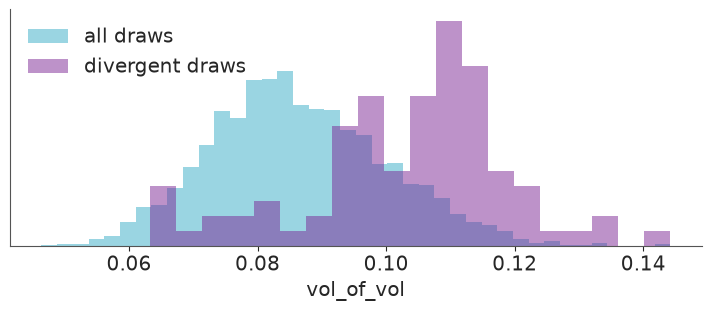

In [15]:
ncp = noncentred_idata.posterior
is_div = noncentred_idata.sample_stats["diverging"].values.ravel()
vov = ncp["vol_of_vol"].values.ravel()
print("divergences per chain:", noncentred_idata.sample_stats["diverging"].sum("draw").values)
print(f"median vol_of_vol: all draws {np.median(vov):.3f}, divergent draws {np.median(vov[is_div]):.3f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(vov, bins=40, density=True, alpha=0.5, label="all draws")
ax.hist(vov[is_div], bins=20, density=True, alpha=0.5, color="C3", label="divergent draws")
ax.set(xlabel="vol_of_vol", yticks=[])
ax.legend();

`vol_of_vol` now has an ESS above a thousand and `r_hat` of 1.00 - the mixing problem is
gone. In exchange we get several dozen **divergences**, spread evenly over the chains and
concentrated at *large* values of `vol_of_vol`.

That pattern is the mirror image of the usual funnel. Non-centring removes the dependence
that comes from the prior but creates one through the likelihood: every $v_t$ is a sum of
*all* earlier innovations times $\sigma_v$, so where the data are informative - and the
larger $\sigma_v$, the more each $z_t$ matters - the posterior of $z$ is narrow and curved,
and a step size tuned to the bulk is too coarse there. Neither parametrisation is ideal
because this model sits between the two regimes: the *level* of volatility is well
identified by the data, its day-to-day *steps* are not.

**Fix 2: a smaller step size.** Raising `target_accept` is a legitimate remedy when
divergences come from a region of moderately higher curvature rather than from a true
funnel neck, *provided you verify* that (a) they disappear and (b) the posterior does not
move. If divergences persist at 0.95-0.99, the model needs rethinking instead.

In [16]:
with noncentred_model:
    sv_idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)

report(sv_idata, "non-centred, target_accept=0.95")

NUTS[nutpie]: [vol_of_vol, nu, mu, log_vol_0, z]


non-centred, target_accept=0.95: 0 divergences; log_vol worst r_hat 1.004, lowest ess_bulk 1311


,mean,sd,ess_bulk,ess_tail,r_hat
vol_of_vol,0.086,0.014,1375.765,2179.778,1.002
nu,16.958,10.190,5138.634,3405.823,1.000
mu,0.109,0.034,7778.553,3567.515,1.000


In [17]:
pd.DataFrame({
    label: az.summary(idata, var_names=["vol_of_vol", "nu", "mu"], kind="stats", round_to=3)["mean"]
    for label, idata in [("centred", centred_idata), ("non-centred", noncentred_idata), ("non-centred, 0.95", sv_idata)]
})

,centred,non-centred,"non-centred, 0.95"
vol_of_vol,0.087,0.086,0.086
nu,16.369,16.728,16.958
mu,0.110,0.109,0.109


In [18]:
assert h.check("task3", vol_of_vol=sv_idata.posterior["vol_of_vol"].mean(), nu=sv_idata.posterior["nu"].mean())

- PASS `vol_of_vol` = 0.08614 is consistent with the reference solution.
- PASS `nu` = 16.96 is consistent with the reference solution.

No divergences, healthy ESS everywhere, and the posterior means agree across all three
fits to within Monte Carlo error - so the divergent run was not badly biased, but now we
*know* that instead of hoping.

Two things to notice in the estimates. Volatility moves by roughly 9% a day. And $\nu$ has
gone from 2 to the high teens: once volatility is allowed to move, the returns *given*
the volatility are only mildly heavier-tailed than a Normal. Most of the "fat tails" of
Task 0 were volatility clustering.

## Task 4 · Does the volatility path make sense?

**Deliver**
1. A plot of the posterior volatility path $e^{v_t}$ (mean and a credible band) over the
   training period, on top of the absolute returns, with the dates you would expect to
   matter marked - at least the Lehman bankruptcy (15 Sep 2008) and the "flash crash"
   (6 May 2010). Report the posterior mean of $e^{v_t}$ on its peak day and on the last
   training day.
2. The predictive checks of Task 1 for this model. Then think about what that check does
   and does not prove here, given that the replications reuse the fitted path, and add a
   check that does not have this weakness.

peak: 4.74% on 2008-10-13;  last training day: 0.96%
constant-volatility estimate: 1.83%


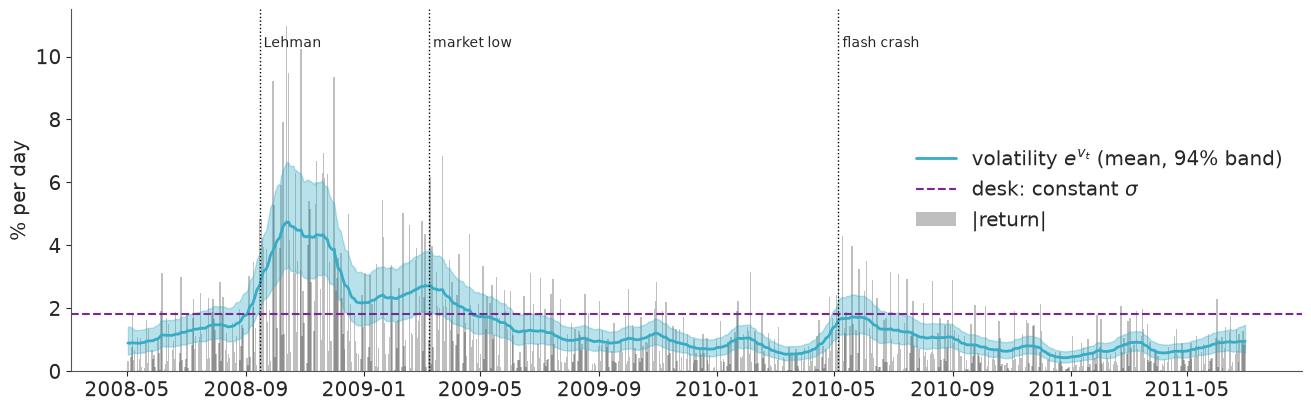

In [19]:
vol = np.exp(sv_idata.posterior["log_vol"])
vol_mean = vol.mean(("chain", "draw")).to_series()
vol_lo, vol_hi = vol.quantile([0.03, 0.97], dim=("chain", "draw")).values

EVENTS = {"Lehman": "2008-09-15", "market low": "2009-03-09", "flash crash": "2010-05-06"}

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(train.index, np.abs(r_train), width=1.5, color="k", alpha=0.25, label="|return|")
ax.fill_between(train.index, vol_lo, vol_hi, color="C0", alpha=0.35)
ax.plot(train.index, vol_mean, color="C0", lw=2, label="volatility $e^{v_t}$ (mean, 94% band)")
ax.axhline(normal_idata.posterior["sigma"].mean(), color="C3", ls="--", label="desk: constant $\\sigma$")
for name, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color="k", lw=1, ls=":")
    ax.text(pd.Timestamp(date), 10.3, " " + name, fontsize=10)
ax.set(ylabel="% per day", ylim=(0, 11.5))
ax.legend(loc="center right")

peak_vol, last_vol = vol_mean.max(), vol_mean.iloc[-1]
print(f"peak: {peak_vol:.2f}% on {vol_mean.idxmax().date()};  last training day: {last_vol:.2f}%")
print(f"constant-volatility estimate: {float(normal_idata.posterior['sigma'].mean()):.2f}%")

In [20]:
assert h.check("task4", peak_vol=peak_vol, last_vol=last_vol)

- PASS `peak_vol` = 4.742 is consistent with the reference solution.
- PASS `last_vol` = 0.9552 is consistent with the reference solution.

The path tells the story of the crisis without having been told any of it: volatility of
a little over 1% a day in the summer of 2008, a climb to a peak of 4.7% in mid-October,
four weeks after Lehman, a slow decay with a second hump around the market low of March
2009, and a smaller episode starting with the flash crash and the first euro-area debt
scare. The desk's single $\sigma$ (dashed) is right on almost no day: far too low until
spring 2009 and close to double the model's estimate for most of the time since. On the
last training day volatility is about half the desk's number.

One detail to remember for Task 6: the path starts climbing *before* Lehman. This is a
**smoothed** estimate - the posterior of $v_t$ uses the returns on both sides of day $t$ -
so it knows what is coming. A forecaster never does.

Sampling: [ret]


{'excess kurtosis': 0.708, 'max |return| (%)': 0.758, 'mean ACF of |return|, lags 1-10': 0.23}


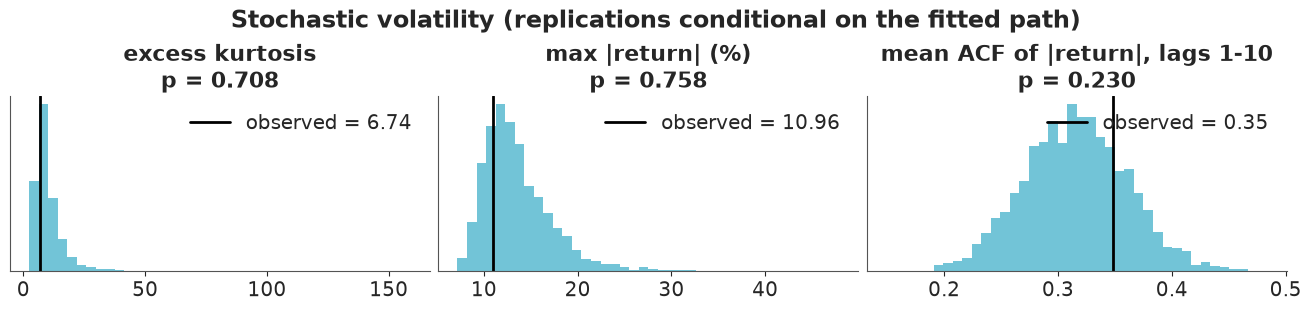

In [21]:
with noncentred_model:
    pm.sample_posterior_predictive(sv_idata, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)

sv_ppp = ppc_stats(sv_idata, "Stochastic volatility (replications conditional on the fitted path)")
print({k: round(v, 3) for k, v in sv_ppp.items()})

All three observed values now fall inside the replicated distributions. But be honest
about how much that proves: the replications are drawn *given the fitted volatility
path*, and that path was estimated from these very returns. Reproducing the clustering is
then close to automatic.

A sharper check asks whether anything is *left over*. If the model is right, the
standardised residuals $(r_t - \mu)/e^{v_t}$ are independent draws from a $t_\nu$: their
absolute values should have no autocorrelation, and their probability integral transform
should be uniform.

ACF of |standardised residuals|: lag 1 -0.11, 2 of 30 lags outside ±0.07, largest |ACF| at lags 2-30: 0.09
PIT bars outside the ±2 sd band: 1 of 20


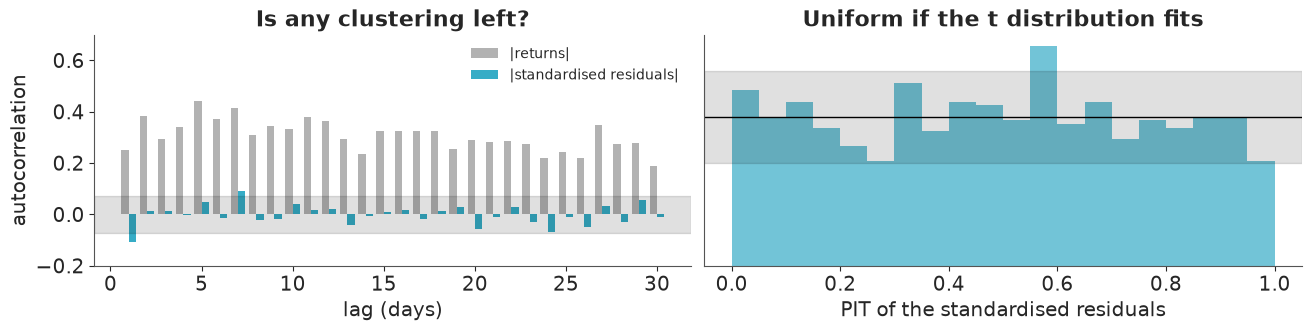

In [22]:
post = az.extract(sv_idata, var_names=["log_vol", "mu", "nu"], num_samples=500, random_seed=RANDOM_SEED)
resid = (r_train[:, None] - post["mu"].values) / np.exp(post["log_vol"].transpose("date", "sample").values)
acf_resid = np.mean([acf(np.abs(resid[:, s]), 30) for s in range(resid.shape[1])], axis=0)  # per draw, averaged
pit = stats.t.cdf(resid, post["nu"].values).mean(axis=1)  # averaged over draws

band = 2 / np.sqrt(T)
print(f"ACF of |standardised residuals|: lag 1 {acf_resid[0]:.2f}, "
      f"{(np.abs(acf_resid) > band).sum()} of 30 lags outside ±{band:.2f}, largest |ACF| at lags 2-30: {np.abs(acf_resid[1:]).max():.2f}")

n_bins = 20
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].bar(lags - 0.2, acf(np.abs(r_train), 30), width=0.4, color="k", alpha=0.3, label="|returns|")
axes[0].bar(lags + 0.2, acf_resid, width=0.4, label="|standardised residuals|")
axes[0].axhspan(-band, band, color="k", alpha=0.12)
axes[0].set(xlabel="lag (days)", ylabel="autocorrelation", title="Is any clustering left?", ylim=(-0.2, 0.7))
axes[0].legend(loc="upper right", fontsize=10)
counts, _, _ = axes[1].hist(pit, bins=n_bins, range=(0, 1), density=True, alpha=0.7)
pit_band = 2 * np.sqrt(n_bins * (1 - 1 / n_bins) / T)  # ±2 sd of a bar height under uniformity
axes[1].axhspan(1 - pit_band, 1 + pit_band, color="k", alpha=0.12)
axes[1].axhline(1, color="k", lw=1)
axes[1].set(xlabel="PIT of the standardised residuals", yticks=[], title="Uniform if the t distribution fits")
print(f"PIT bars outside the ±2 sd band: {(np.abs(counts - 1) > pit_band).sum()} of {n_bins}");

The clustering has been absorbed by $v_t$: from 0.2-0.45 at every lag, the
autocorrelation of the absolute residuals drops into the white-noise band at 28 of 30
lags. The exception worth a note is lag 1, which is mildly *negative* (about -0.1): after
a large standardised move the next one tends to be a little smaller than the model
expects. That is small next to what we started with, and a random walk has no way to
produce it. The PIT histogram is flat to within sampling noise (one bar of 20 outside the
±2 sd band).

Keep in mind that every in-sample check on a model with a latent variable per observation
flatters the model. The test that counts is out of sample, which is where we go next.

## Task 5 · Tomorrow's number

It is the evening of 30 June 2011, the last training day.

**Deliver** the one-day-ahead 99% VaR for 1 July 2011 - the 1% quantile of the posterior
predictive distribution of tomorrow's return, in percent (a negative number) - under the
desk's model and under yours. Tomorrow's volatility is not in your posterior: get it there.
Propagate **all** the uncertainty (parameters, today's volatility, tomorrow's shock).

In [23]:
def var_constant(idata, dist, q=0.01, n_rep=50):
    """q-quantile of the posterior predictive of a constant-parameter model: a new return per draw."""
    p = az.extract(idata)
    size = (n_rep, p.sizes["sample"])
    if dist == "normal":
        draws = rng.normal(p["mu"].values, p["sigma"].values, size=size)
    else:
        draws = p["mu"].values + p["sigma"].values * rng.standard_t(p["nu"].values, size=size)
    return np.quantile(draws, q)


p = az.extract(sv_idata, var_names=["log_vol", "vol_of_vol", "nu", "mu"])
log_vol_T = p["log_vol"].isel(date=-1).values
size = (50, log_vol_T.size)  # 50 futures per posterior draw
log_vol_next = log_vol_T + p["vol_of_vol"].values * rng.standard_normal(size)  # one step of the walk
ret_next = p["mu"].values + np.exp(log_vol_next) * rng.standard_t(p["nu"].values, size=size)

var_desk = var_constant(normal_idata, "normal")
var_student = var_constant(student_idata, "student")
var_sv = np.quantile(ret_next, 0.01)
print(f"99% VaR for {test.index[0].date()}:  desk {var_desk:.2f}%   constant Student-t {var_student:.2f}%   SV {var_sv:.2f}%")

99% VaR for 2011-07-01:  desk -4.26%   constant Student-t -5.99%   SV -2.66%


In [24]:
assert h.check("task5", var_desk=var_desk, var_sv=var_sv)

- PASS `var_desk` = -4.261 is consistent with the reference solution.
- PASS `var_sv` = -2.657 is consistent with the reference solution.

The random walk makes the forecast a two-liner: tomorrow's log-volatility is today's plus
one more `Normal(0, vol_of_vol)` shock, per posterior draw; then a Student-t return given
that volatility. Taking the quantile over *all* simulated returns integrates over
parameter uncertainty, uncertainty about today's volatility, and tomorrow's shock.

In the calm of June 2011 the stochastic-volatility VaR is 1.6 percentage points smaller
than the desk's - less than two thirds of the capital. The constant Student-t is the most
conservative of the three: its $\nu \approx 2$ tails make it *worse* than the Normal as a
description of a quiet market.

## Task 6 · Back-test, and recommend

Now the verdict. For **every** day in `test` you need the VaR that would have been
published the evening before, using only returns up to that evening.

**Deliver**
1. The daily VaR series of your model and of the desk's model over the test period, in
   one plot with the realised returns, exceedances marked.
2. The number of exceedances of each against the expected 1%, *when* they happened, and
   the average VaR (a proxy for the capital the desk must hold).
3. A recommendation to the head of risk in a short paragraph - including what your model
   still gets wrong.

Refitting an 800-parameter model 629 times is not an option, and fitting once on
train + test would let each day's volatility estimate peek at the future. Find a way to
update your belief about *today's volatility* day by day that is cheap and does not
cheat, and state clearly which shortcut you are taking.

### Solution

**The shortcut.** The static parameters ($\sigma_v$, $\nu$, $\mu$) are *frozen* at their
training posterior: we keep the draws, but never update them with test data. Only the
latent volatility is updated each day. A production system would refit the parameters
every few months; since they describe slow features of the market this matters little
over 2.5 years, but it *is* an approximation, and it means the parameters were learnt
from a period dominated by a crisis.

**The update** is a bootstrap particle filter, which is nothing more than Bayes' rule by
simulation, one day at a time. For each of `D` posterior draws of the parameters we carry
`M` particles - guesses of today's log-volatility, started at that draw's $v_T$. Each day:

1. **predict**: move every particle one random-walk step and simulate a return from it;
   the 1% quantile of all simulated returns is tomorrow's VaR (exactly Task 5);
2. **update**: once the real return is known, weight each particle by its Student-t
   likelihood and resample particles in proportion to the weights.

Particles whose volatility made the observed return plausible survive; the others die.
No information from the future is ever used.

In [25]:
def filter_forecasts(r_new, log_vol_last, vol_of_vol, nu, mu, n_particles, quantiles=(0.01, 0.99)):
    """Bootstrap particle filter with frozen static parameters (one row per posterior draw).

    Returns the one-day-ahead predictive quantiles and the filtered volatility (3%, 50%, 97%) per day.
    """
    D = len(log_vol_last)
    row = np.arange(D)[:, None]
    v = np.repeat(log_vol_last[:, None], n_particles, axis=1)  # (D, M)
    pred_q = np.empty((len(r_new), len(quantiles)))
    vol_q = np.empty((len(r_new), 3))
    for t, r_t in enumerate(r_new):
        # predict
        v = v + vol_of_vol[:, None] * rng.standard_normal(v.shape)
        r_rep = mu[:, None] + np.exp(v) * rng.standard_t(nu[:, None], size=v.shape)
        pred_q[t] = np.quantile(r_rep, quantiles)
        # update
        logw = stats.t.logpdf(r_t, nu[:, None], mu[:, None], np.exp(v))
        w = np.exp(logw - logw.max(axis=1, keepdims=True))
        w /= w.sum(axis=1, keepdims=True)
        # systematic resampling within each row, vectorised by offsetting row i's CDF by i
        u = (rng.random((D, 1)) + np.arange(n_particles)) / n_particles
        idx = np.searchsorted((np.cumsum(w, axis=1) + row).ravel(), (u + row).ravel()).reshape(D, -1)
        v = np.take_along_axis(v, np.clip(idx - row * n_particles, 0, n_particles - 1), axis=1)
        vol_q[t] = np.quantile(np.exp(v), [0.03, 0.5, 0.97])
    return pred_q, vol_q


r_test = test["ret"].values
keep = rng.choice(p.sizes["sample"], 300, replace=False)  # 300 parameter draws x 200 particles
pred_q, vol_filtered = filter_forecasts(
    r_test, log_vol_T[keep], p["vol_of_vol"].values[keep], p["nu"].values[keep], p["mu"].values[keep], n_particles=200
)
var_sv_series = pd.Series(pred_q[:, 0], index=test.index)
print(f"first test day: filter VaR {var_sv_series.iloc[0]:.2f}%  vs  Task 5 {var_sv:.2f}%")

first test day: filter VaR -2.64%  vs  Task 5 -2.66%


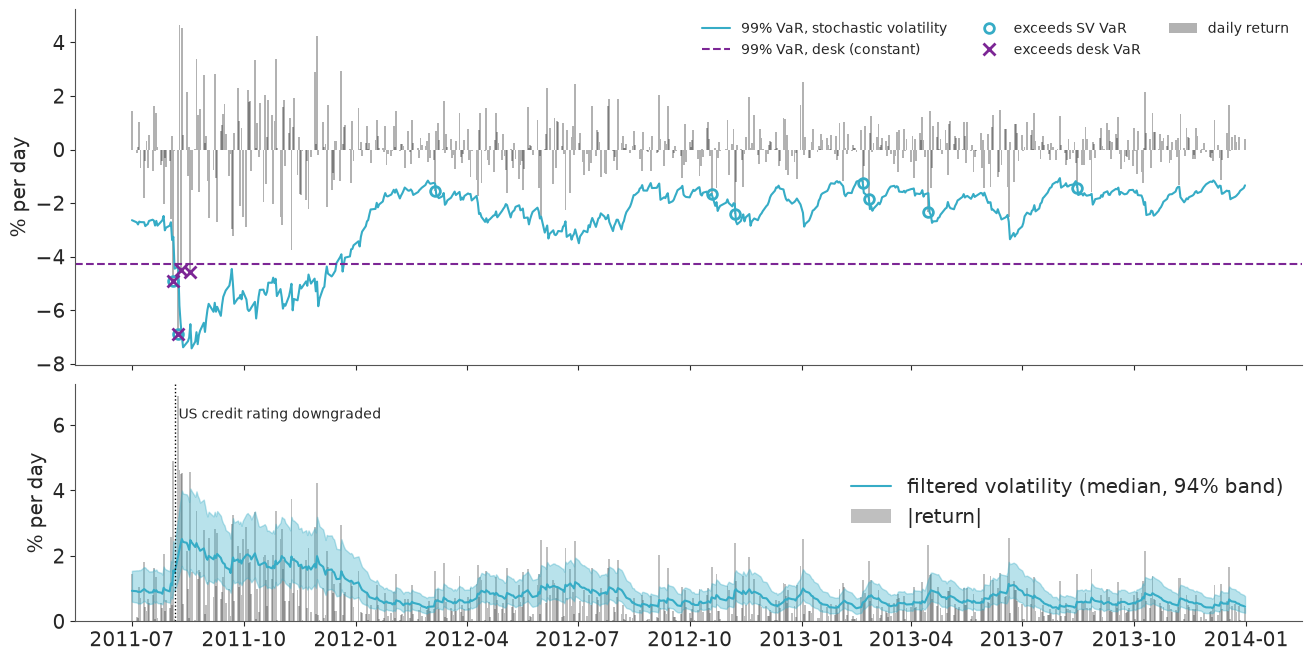

In [26]:
exceed_sv = r_test < var_sv_series.values
exceed_desk = r_test < var_desk

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True, height_ratios=[3, 2])
axes[0].bar(test.index, r_test, width=1.5, color="k", alpha=0.3, label="daily return")
axes[0].plot(test.index, var_sv_series, color="C0", lw=1.5, label="99% VaR, stochastic volatility")
axes[0].axhline(var_desk, color="C3", ls="--", label="99% VaR, desk (constant)")
axes[0].plot(test.index[exceed_sv], r_test[exceed_sv], "o", color="C0", ms=7, mfc="none", mew=2, label="exceeds SV VaR")
axes[0].plot(test.index[exceed_desk], r_test[exceed_desk], "x", color="C3", ms=8, mew=2, label="exceeds desk VaR")
axes[0].set(ylabel="% per day")
axes[0].legend(ncols=3, loc="upper right", fontsize=10)

axes[1].bar(test.index, np.abs(r_test), width=1.5, color="k", alpha=0.25, label="|return|")
axes[1].fill_between(test.index, vol_filtered[:, 0], vol_filtered[:, 2], color="C0", alpha=0.35)
axes[1].plot(test.index, vol_filtered[:, 1], color="C0", label="filtered volatility (median, 94% band)")
axes[1].axvline(pd.Timestamp("2011-08-05"), color="k", lw=1, ls=":")
axes[1].text(pd.Timestamp("2011-08-05"), 6.2, " US credit rating downgraded", fontsize=10)
axes[1].set(ylabel="% per day")
axes[1].legend(loc="center right");

In [27]:
def backtest_row(var_series, label):
    """Exceedance counts, a Beta(1,1)-prior posterior for the exceedance rate, timing and average VaR."""
    exceed = r_test < var_series
    k, n = int(exceed.sum()), len(r_test)
    lo, hi = stats.beta.ppf([0.03, 0.97], 1 + k, 1 + n - k)
    turbulent = test.index < "2012-01-01"
    return {
        "model": label,
        "exceedances": k,
        "rate (%)": round(100 * k / n, 2),
        "94% interval for rate (%)": f"{100 * lo:.1f} - {100 * hi:.1f}",
        "Jul-Dec 2011": f"{exceed[turbulent].sum()} / {turbulent.sum()}",
        "2012-2013": f"{exceed[~turbulent].sum()} / {(~turbulent).sum()}",
        "mean VaR (%)": round(float(np.mean(var_series)), 2),
    }


print(f"expected at 1%: {0.01 * len(r_test):.1f} exceedances in {len(r_test)} days")
print("desk exceedances:", list(test.index[exceed_desk].strftime("%Y-%m-%d")))
print("SV exceedances:  ", list(test.index[exceed_sv].strftime("%Y-%m-%d")))
upper = int((r_test > pred_q[:, 1]).sum())
print(f"SV, other tail: {upper} days above the 99% predictive quantile")
print("SV VaR around the August 2011 sell-off:")
print(pd.DataFrame({"return": test["ret"], "SV VaR": var_sv_series}).loc["2011-08-03":"2011-08-11"].round(2).T.to_string())

pd.DataFrame([
    backtest_row(np.full(len(r_test), var_desk), "desk: constant Normal"),
    backtest_row(np.full(len(r_test), var_student), "constant Student-t"),
    backtest_row(var_sv_series.values, "stochastic volatility"),
]).set_index("model")

expected at 1%: 6.3 exceedances in 629 days
desk exceedances: ['2011-08-04', '2011-08-08', '2011-08-10', '2011-08-18']
SV exceedances:   ['2011-08-04', '2011-08-08', '2012-03-06', '2012-10-19', '2012-11-07', '2013-02-20', '2013-02-25', '2013-04-15', '2013-08-15']
SV, other tail: 1 days above the 99% predictive quantile
SV VaR around the August 2011 sell-off:
Date    2011-08-03  2011-08-04  2011-08-05  2011-08-08  2011-08-09  2011-08-10  2011-08-11
return        0.50       -4.90       -0.06       -6.90        4.63       -4.52        4.53
SV VaR       -3.38       -3.26       -4.45       -4.37       -5.84       -6.49       -6.97


,exceedances,rate (%),94% interval for rate (%),Jul-Dec 2011,2012-2013,mean VaR (%)
model,,,,,,
desk: constant Normal,4,0.64,0.3 - 1.6,4 / 127,0 / 502,-4.26
constant Student-t,1,0.16,0.0 - 0.8,1 / 127,0 / 502,-5.99
stochastic volatility,9,1.43,0.8 - 2.6,2 / 127,7 / 502,-2.58


In [28]:
assert h.check("task6", exceed_desk=int(exceed_desk.sum()), exceed_sv=int(exceed_sv.sum()))

- PASS `exceed_desk` = 4 is consistent with the reference solution.
- PASS `exceed_sv` = 9 is consistent with the reference solution.

**What the back-test says**

- **The count alone does not separate the models.** Against 6.3 expected exceedances the
  desk's VaR was breached 4 times and the stochastic-volatility VaR 9 times. Over 629
  days both are compatible with a true rate of 1% (the 94% intervals are 0.3-1.6% and
  0.8-2.6%). A regulator who only counts passes both, and likes the desk's model better.
- **The timing does.** All four of the desk's exceedances fall within eleven trading days
  in August 2011, followed by none at all in the 502 days of 2012-13. That is the head of
  risk's complaint in numbers: a VaR that fails in clusters fails exactly when it is
  needed, and one that is never approached for two years is not measuring risk. The new
  model is also caught on 4 and 8 August - a filter cannot anticipate a jump in
  volatility, only react to it - but it reacts within days: its VaR goes from -3.3% on
  4 August to -6.5% on 10 August, so the two later August losses that breach the desk's
  number are covered. Its other seven exceedances are spread over the following two
  years, never more than two in a month.
- **The capital.** The average VaR is 2.6% for the new model against 4.3% for the desk,
  which holds about 65% more capital on average and was still under-protected in the one
  episode that mattered. The constant Student-t is the worst of both worlds: 6.0% every
  day, and breached on 8 August all the same.
- **What the new model still gets wrong.** Nine returns fell below its 1% quantile but
  only one rose above its 99% quantile, where about six are expected on each side. The
  predictive distribution is symmetric and the market is not: falls are sharper than
  rallies, and volatility rises after falls. With nine against one this is more than a
  hint, even though the lower-tail count on its own is still compatible with 1%.

**Recommendation.** Replace the constant-volatility model. The stochastic-volatility VaR
tracks risk - it doubled within a week in August 2011 and released capital again
as markets calmed - and its exceedances do not cluster. Two caveats go with it. Its
downside coverage ran at about 1.4% rather than 1%, most likely because it ignores the
asymmetry of returns; that should be modelled (see *Going further*) before anyone relies
on the second decimal. And the back-test froze the parameters in June 2011 and only
filtered the volatility; in production they should be refitted on a schedule.

## Going further

- **Leverage.** Let the shock to tomorrow's volatility be negatively correlated with
  today's return, or give the returns a skewed distribution. Does the lower-tail coverage
  in the back-test improve, and what happens to the upper tail?
- **Mean reversion.** Replace the random walk by an AR(1) log-volatility,
  $v_t = \bar v + \phi\,(v_{t-1} - \bar v) + \sigma_v \epsilon_t$. How well is $\phi$
  identified, and does it change the 10-day-ahead VaR more than the 1-day-ahead one?
- **Check the shortcut.** Refit the model on all data up to the end of 2012 and compare
  its volatility on the last day, and its parameters, with what the particle filter
  carried forward from June 2011.
- **Expected shortfall.** Regulators have moved from VaR to the expected loss *beyond* the
  VaR. You have the predictive draws: compute it, and think about how you would back-test it.

In [29]:
h.progress()

**C07**: 0/21 hints used, 13/13 checks passed.